In [1]:
import pickle
from torch.utils.data import Subset
from torch_geometric.datasets import BA2MotifDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv,global_add_pool
from torch_geometric.loader import DataLoader
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import random_split
import matplotlib.pyplot as plt

from utils.data import load_data,dataset_description
from utils.models import GINGraphClf,train_one_epoch,evaluate,test_evaluation




c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_spline_conv\_version_cpu.pyd
  import torch_geometric.typing
c:

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## loading data and split

In [3]:
dataset=load_data(with_gt=True)
with open("./data/splits.pkl", "rb") as f:
    splits=pickle.load(f)

train_dataset=Subset(dataset,splits["train"])
val_dataset=Subset(dataset,splits["val"])
test_dataset=Subset(dataset,splits["test"])


Processing...
Done!


In [4]:

config={
    'hidden_dim':64,
    'learning_rate':0.001,
    'weight_decay':0.001,
    'epochs':100,
    'batch_size':32,
    'patience':10           # early stopping
}



In [5]:
train_loader=DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
validation_loader=DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=config['batch_size'],shuffle=False)

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Training

In [7]:
print(f"num_classes: {dataset.num_classes}")          # باید 2 باشد
print(f"sample y: {dataset[0].y.item()}")            # باید 0 یا 1 باشد
print(f"has node_mask: {hasattr(dataset[0], 'node_mask')}")

num_classes: 2
sample y: 0
has node_mask: True


In [8]:
dataset_description(dataset=dataset,sample_index=10)

lenght of dataset : 1000
number of class : 2
number of features : 10
 construction of first graph :
 edge matrix : torch.Size([2, 48])
 nodes features : torch.Size([25, 10])
 label : 0

Sample 10:
1. Node features (x): shape = torch.Size([25, 10])
   First 2 rows (if enough nodes):
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
2. Edge index (edge_index): shape = torch.Size([2, 48])
   Number of edges: 48
   First 5 edges (source -> target):
tensor([[ 0,  2],
        [ 0,  4],
        [ 0,  6],
        [ 0, 10],
        [ 0, 13]])
3. Graph label (y): 0 -> Negative (Cycle motif)
4. No motif mask found in this dataset sample.

All attributes of this data object:
   - batch: None
   - edge_attr: None
   - edge_index: tensor of shape torch.Size([2, 48])
   - edge_weight: None
   - face: None
   - is_cuda: False
   - node_offsets: {None: 0}
   - num_edge_features: 0
   - num_edge_types: 1
   - num_edges: 48
   - num_faces: None
   - num_

e:\arshad\term 2\ADL\GNN\project\Subgraph-explanablity-on-GNN\utils\data.py:66: UserWarning: 'num_faces' is deprecated, use 'data.face.size(-1)' instead
  val = getattr(data, attr)


In [9]:
model=GINGraphClf(dataset.num_node_features,dataset.num_classes).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
criterion=nn.CrossEntropyLoss()

In [10]:
best_val_acc=0.0
patience_counter=0
best_model_state=None

train_losses = []
val_accs = []


with tqdm(total=config["epochs"],desc="Training epochs",unit="epoch") as pbar_epoch:
    for epoch in range(config["epochs"]):
        train_loss=train_one_epoch(model,train_loader,optimizer,criterion,device)
        val_acc=evaluate(model,validation_loader,device)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        pbar_epoch.set_postfix({"train_loss":train_loss,"val_acc":val_acc})
        pbar_epoch.update(1)
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            patience_counter=0
            best_model_state=model.state_dict().copy()
        else:
            patience_counter+=1
            if patience_counter>=config["patience"]:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                break

model.load_state_dict(best_model_state)
tqdm.write(f"Best validation accuracy: {best_val_acc:.4f}")

Training epochs:  13%|█▎        | 13/100 [00:03<00:23,  3.75epoch/s, train_loss=0.316, val_acc=0.53]

Early stopping at epoch 13
Best validation accuracy: 1.0000


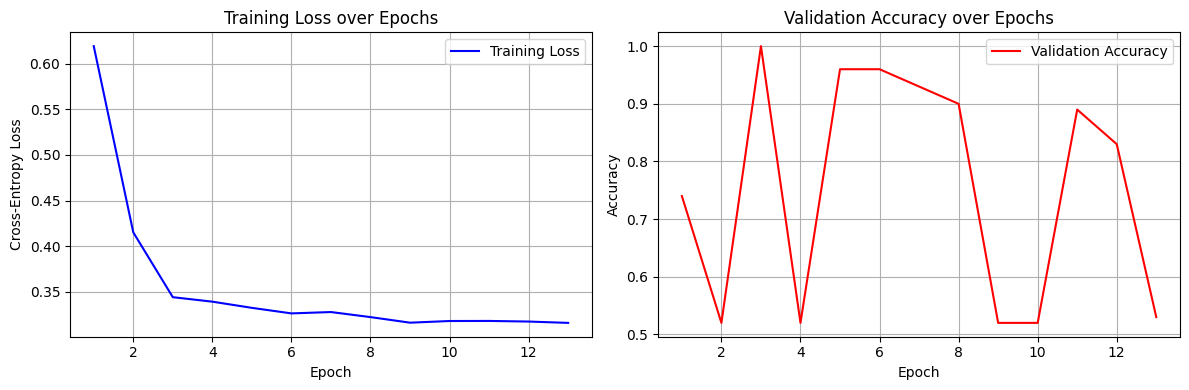

In [11]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model.eval()
for param in model.parameters():
    param.requires_grad=False

torch.save({
    'model_state_dict':best_model_state,
    'config':config,
    'best_val_acc':best_val_acc,
},"./models/GIN/best_gin_model.pt"
)
tqdm.write(" Model frozen and saved as 'best_gin_model.pt'")

 Model frozen and saved as 'best_gin_model.pt'


## Evaluating

In [13]:
model=GINGraphClf(test_dataset[0].num_features,2).to(device)

checkpoint=torch.load('./models/GIN/best_gin_model.pt',map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()
for param in model.parameters():
    param.requires_grad = False


In [14]:
test_acc ,correct_indices,wrong_indices= test_evaluation(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of correct predictions: {len(correct_indices)}")

Test Accuracy: 0.4500
Number of correct predictions: 45


In [15]:
test_result_split={
    "correct": correct_indices,
    "wrong": wrong_indices
}
with open('./data/test_result.pkl','wb') as f:
    pickle.dump(test_result_split,f)

print("data indices saved to ./data/test_result.pkl")

data indices saved to ./data/test_result.pkl


# Explanation

### Baseline

In [16]:
from utils.graph_function import baseline_explanation,subgraph_explanation
from utils.visualization import visualize_explanation

In [17]:
fidelity_dorp_score=0
total_precision = 0
total_recall = 0
total_fidelity = 0



for key in test_result_split.keys():
    if len(test_result_split[key]) == 0:
        continue
    max_pic=10
    if len(test_result_split[key])<max_pic:
        max_pic=len(test_result_split[key])
        random_indices=list(range(0, len(test_result_split[key])))
    
    else:
        random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()

    for i in range(len(test_result_split[key])):
        data=test_dataset[test_result_split[key][i]['index']]
        pred_class=test_result_split[key][i]['pred']
        explanation_graph, selected_nodes,fidelity_score = baseline_explanation(
            model, data, target_class=pred_class, budget=0.2, device=device
        )


        selected_set = set(selected_nodes)
        gt_set = set(data.motif_nodes.tolist())
        print(f"gt : {gt_set}")
        print(f"selected node : {selected_nodes}")
        intersection = len(selected_set.intersection(gt_set))
        len_selected = len(selected_set)
        len_gt = len(gt_set)


        precision = intersection / len_selected if len_selected > 0 else 0
        recall = intersection / len_gt if len_gt > 0 else 0
        
        total_precision += precision
        total_recall += recall

        print(f"precision: {precision} , recall : {recall}")
        fidelity_dorp_score+=fidelity_score
        if i in random_indices:
            visualize_explanation(data.cpu(), selected_nodes,save_path=f"./explanation/baseline/{key}/index_{test_result_split[key][i]['index']}.png")  


percision_score=total_precision / len(test_dataset)
recall_score=total_recall / len(test_dataset)
f1_score = 2 * (percision_score * recall_score) / (percision_score + recall_score)
print(f" fidelity score: {fidelity_dorp_score/len(test_dataset):.4f}")
print(f"Precision score: {percision_score:.4f}")
print(f"Recall score: {recall_score:.4f}")
print(f"F1 score: {f1_score:.4f}")


gt : {20, 21, 22, 23, 24}
selected node : [22, 20, 24, 21, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 22, 24, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 24, 21, 23, 22]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 24, 21, 23, 22]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 22, 24, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [23, 20, 21, 22, 24]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [23, 24, 20, 22, 21]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [23, 24, 21, 20, 22]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [23, 24, 20, 22, 21]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 22, 24, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [22, 23, 21, 24, 20]
precisi

### Subgraph Explanation

In [18]:
fidelity_dorp_score=0
total_precision = 0
total_recall = 0
total_fidelity = 0


for key in test_result_split.keys():
    if len(test_result_split[key]) == 0:
        continue
    max_pic=10
    if len(test_result_split[key])<max_pic:
        max_pic=len(test_result_split[key])
        random_indices=list(range(0, len(test_result_split[key])))
    
    else:
        random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()
    
    random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()
    for i in range(len(test_result_split[key])):
        data=test_dataset[test_result_split[key][i]['index']]
        pred_class=test_result_split[key][i]['pred']
        explanation_graph, removed_nodes,fidelity_score = subgraph_explanation(
            model, data, target_class=pred_class, budget=0.2, device=device
        )

        
        selected_set = set(selected_nodes)
        gt_set = set(data.motif_nodes.tolist())
        print(f"gt : {gt_set}")
        print(f"selected node : {selected_nodes}")
        intersection = len(selected_set.intersection(gt_set))
        len_selected = len(selected_set)
        len_gt = len(gt_set)


        precision = intersection / len_selected if len_selected > 0 else 0
        recall = intersection / len_gt if len_gt > 0 else 0
        
        total_precision += precision
        total_recall += recall

        print(f"precision: {precision} , recall : {recall}")
        fidelity_dorp_score+=fidelity_score
        if i in random_indices:
            all_nodes = set(range(data.num_nodes))
            remaining_nodes = list(all_nodes - set(removed_nodes))
            visualize_explanation(data.cpu(), remaining_nodes,save_path=f"./explanation/subgraph_explanation/{key}/index_{test_result_split[key][i]['index']}.png")  

percision_score=total_precision / len(test_dataset)
recall_score=total_recall / len(test_dataset)
f1_score = 2 * (percision_score * recall_score) / (percision_score + recall_score)
print(f" fidelity score: {fidelity_dorp_score/len(test_dataset):.4f}")
print(f"Precision score: {percision_score:.4f}")
print(f"Recall score: {recall_score:.4f}")
print(f"F1 score: {f1_score:.4f}")

gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precision: 1.0 , recall : 1.0
gt : {20, 21, 22, 23, 24}
selected node : [20, 21, 24, 22, 23]
precisi